<a href="https://colab.research.google.com/github/P-Karthikeya512/Research-study-on-UNET/blob/main/Baseline_UNET(BUSI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split

# =========================
# CONFIG
# =========================
IMG_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 50
SEED = 42

ZIP_PATH = "/content/Dataset_BUSI_with_GT.zip"
EXTRACT_DIR = "/content/BUSI_DATASET"

import zipfile
from pathlib import Path

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

def find_dataset_root(base_dir):
    for root, dirs, files in os.walk(base_dir):
        d = {x.lower() for x in dirs}
        if {"benign", "malignant", "normal"}.issubset(d):
            return root
    raise FileNotFoundError("Could not find benign/malignant/normal folders.")

DATASET_DIR = find_dataset_root(EXTRACT_DIR)

print("Dataset:", DATASET_DIR)

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


Dataset: /content/BUSI_DATASET/Dataset_BUSI_with_GT


In [ ]:
def get_pairs(dataset_dir):
    pairs = []

    for cls in ["benign", "malignant", "normal"]:
        folder = os.path.join(dataset_dir, cls)
        for f in sorted(os.listdir(folder)):
            path = os.path.join(folder, f)
            if not os.path.isfile(path):
                continue
            ext = Path(f).suffix.lower()
            if ext not in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
                continue
            stem = Path(f).stem
            if "_mask" in stem.lower():
                continue
            mask = os.path.join(folder, stem + "_mask.png")
            if os.path.exists(mask):
                pairs.append((path, mask))
            else:
                print("No mask:", path)

    return pairs


# =========================
# LOAD ONE IMAGE + MASK
# =========================
def load_image_mask(img_path, mask_path):
    if isinstance(img_path, bytes):
        img_path = img_path.decode()

    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode()

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")

    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

def tf_load_image_mask(img_path, mask_path):
    img, mask = tf.numpy_function(
        func=load_image_mask,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    mask.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
    return img, mask

# =========================
# AUGMENTATION
# =========================
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    return image, mask

# =========================
# CREATE DATASET
# =========================

pairs = get_pairs(DATASET_DIR)

print("Total paired samples:", len(pairs))

for img, mask in pairs[:3]:
    print(img)
    print(mask)
    print()


Total paired samples: 780
/content/BUSI_DATASET/Dataset_BUSI_with_GT/benign/benign (1).png
/content/BUSI_DATASET/Dataset_BUSI_with_GT/benign/benign (1)_mask.png

/content/BUSI_DATASET/Dataset_BUSI_with_GT/benign/benign (10).png
/content/BUSI_DATASET/Dataset_BUSI_with_GT/benign/benign (10)_mask.png

/content/BUSI_DATASET/Dataset_BUSI_with_GT/benign/benign (100).png
/content/BUSI_DATASET/Dataset_BUSI_with_GT/benign/benign (100)_mask.png



Train samples: 624
Val samples: 156


Model: "UNet_Binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_90 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 256, 256,  │      9,248 │ re_lu_90[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_91 (ReLU)     │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 128, 128,  │          0 │ re_lu_91[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 128, 128,  │          0 │ max_pooling2d_20… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 128, 128,  │     18,496 │ dropout_40[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_92 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 128, 128,  │     36,928 │ re_lu_92[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_93 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 64, 64,    │          0 │ re_lu_93[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 64, 64,    │          0 │ max_pooling2d_21

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.2724 - dice_coef: 0.1309 - iou_coef: 0.0705 - loss: 1.8687
Epoch 1: val_dice_coef improved from None to 0.16462, saving model to best_unet.keras

Epoch 1: finished saving model to best_unet.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 51s 242ms/step - accuracy: 0.4479 - dice_coef: 0.1336 - iou_coef: 0.0722 - loss: 1.6886 - val_accuracy: 0.5229 - val_dice_coef: 0.1646 - val_iou_coef: 0.0910 - val_loss: 1.6299 - learning_rate: 1.0000e-04
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8916 - dice_coef: 0.1352 - iou_coef: 0.0732 - loss: 1.3880
Epoch 2: val_dice_coef did not improve from 0.16462
78/78 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 0.9081 - dice_coef: 0.1335 - iou_coef: 0.0723 - loss: 1.3587 - val_accuracy: 0.9061 - val_dice_coef: 0.1503 - val_iou_coef: 0.0821 - val_loss: 1.3567 - learning_rate: 1.0000e-04
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9291 - dice_coef: 0.1312 - iou_

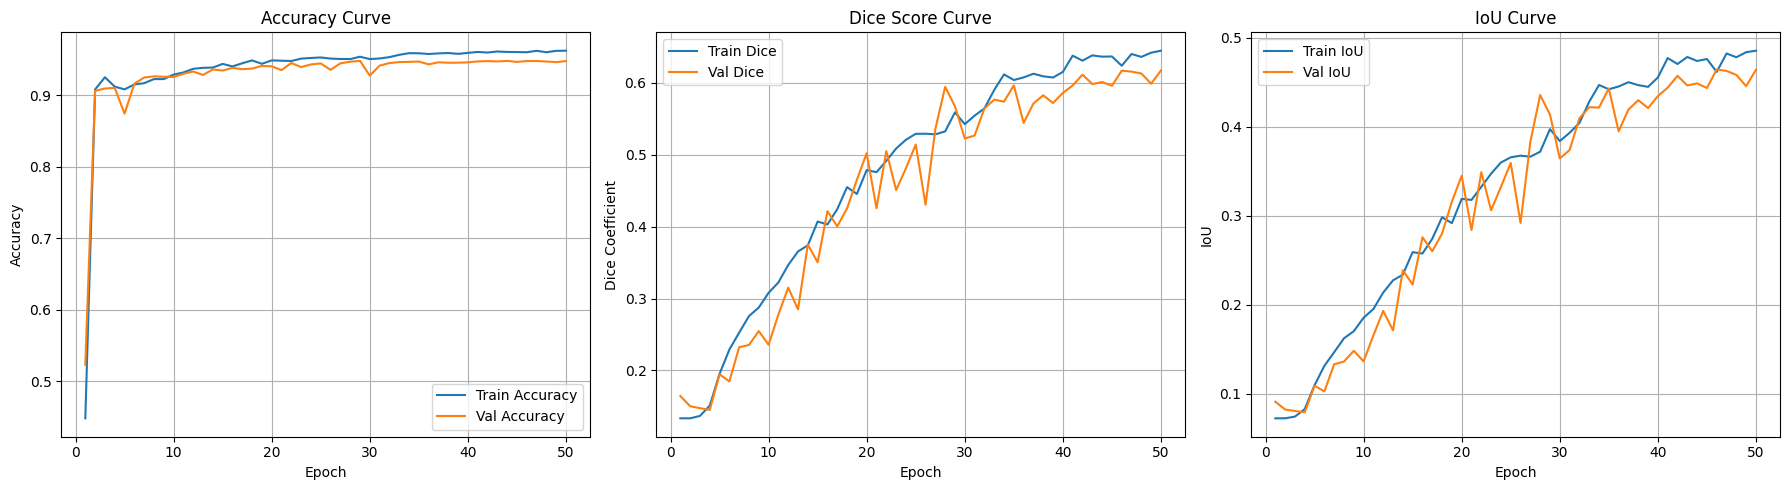

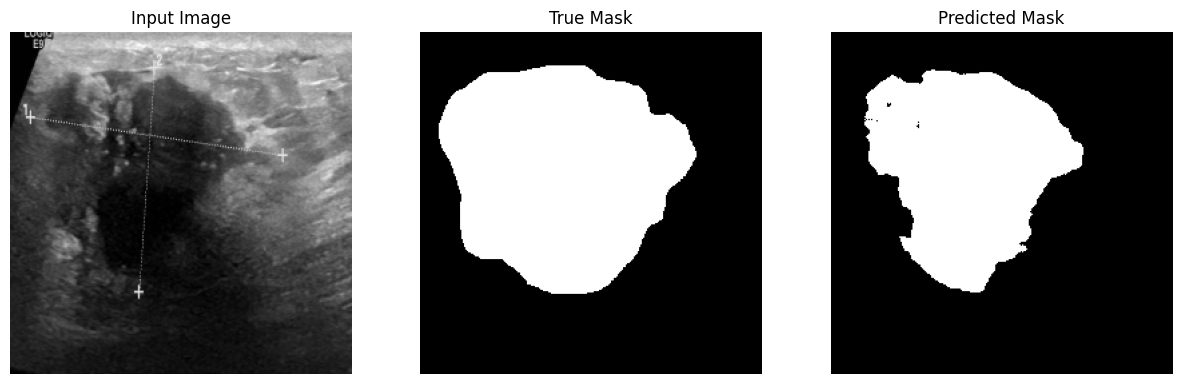

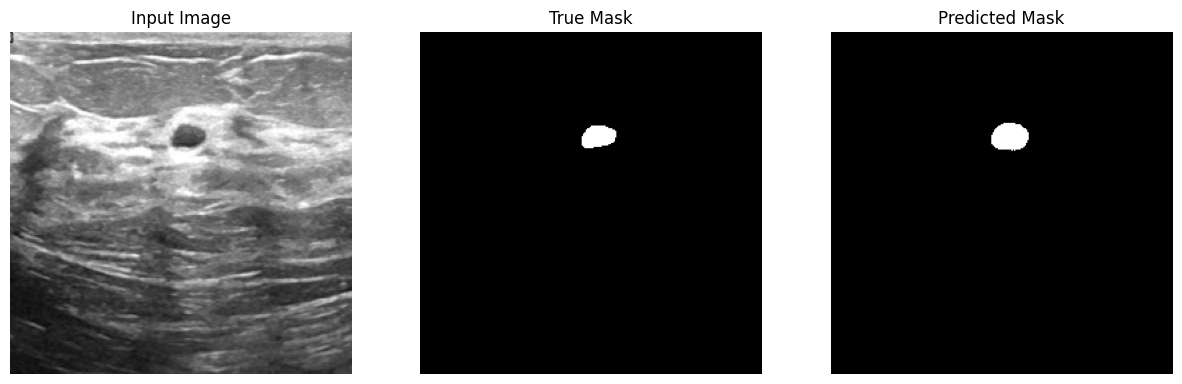

In [ ]:
def make_dataset(pairs, training=True):
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    if training:
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

labels = [Path(img).parent.name for img, mask in pairs]
train_pairs, val_pairs = train_test_split(pairs, test_size=0.2, random_state=SEED, stratify=labels)

train_ds = make_dataset(train_pairs, training=True)
val_ds = make_dataset(val_pairs, training=False)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))

# =========================
# METRICS / LOSS
# =========================
def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# =========================
# U-NET BUILDING BLOCKS
# =========================
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def down_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPool2D((2, 2))(c)
    p = layers.Dropout(0.2)(p)
    return c, p

def up_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Dropout(0.2)(x)
    x = conv_block(x, filters)
    return x

# =========================
# BUILD U-NET
# =========================
def build_unet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)

    s1, p1 = down_block(inputs, 32)
    s2, p2 = down_block(p1, 64)
    s3, p3 = down_block(p2, 128)
    s4, p4 = down_block(p3, 256)

    bottleneck = conv_block(p4, 512)

    u1 = up_block(bottleneck, s4, 256)
    u2 = up_block(u1, s3, 128)
    u3 = up_block(u2, s2, 64)
    u4 = up_block(u3, s1, 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(u4)

    model = Model(inputs, outputs, name="UNet_Binary")
    return model

model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=["accuracy", dice_coef, iou_coef]
)

model.summary()

# =========================
# CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

# =========================
# TRAIN
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# =========================
# PLOTS: ACCURACY, DICE, IOU
# =========================
def plot_training_curves(history):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(18, 5))

    # Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, hist["val_accuracy"], label="Val Accuracy")
    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Dice Score
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, hist["dice_coef"], label="Train Dice")
    plt.plot(epochs_range, hist["val_dice_coef"], label="Val Dice")
    plt.title("Dice Score Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Coefficient")
    plt.legend()
    plt.grid(True)

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, hist["iou_coef"], label="Train IoU")
    plt.plot(epochs_range, hist["val_iou_coef"], label="Val IoU")
    plt.title("IoU Curve")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

# =========================
# PREDICTION + VISUALIZATION
# =========================
def show_prediction(model, pair):
    img_path, mask_path = pair
    img, mask = load_image_mask(img_path.encode(), mask_path.encode())

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

# Show one validation sample
show_prediction(model, val_pairs[9])
show_prediction(model, val_pairs[10])

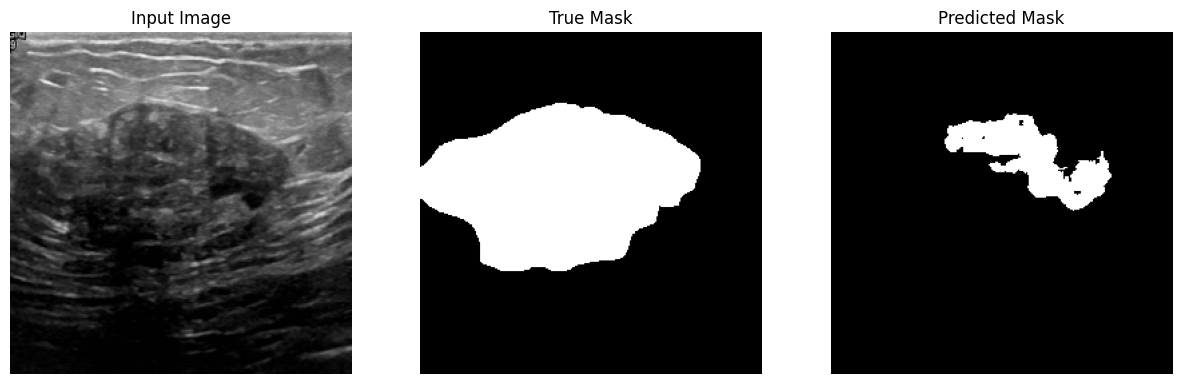

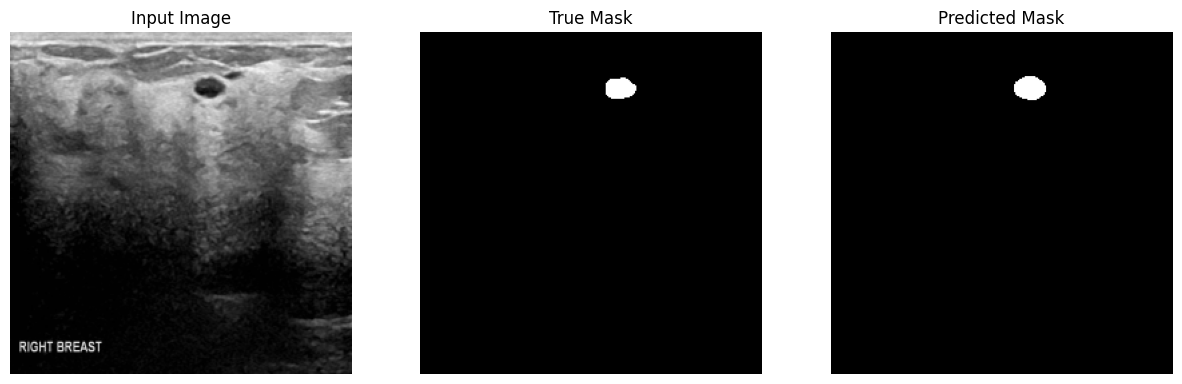

In [ ]:
show_prediction(model, val_pairs[80])
show_prediction(model, val_pairs[79])

In [ ]:
empty = 0

for img_path, mask_path in pairs:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is None:
        continue

    if np.count_nonzero(mask) == 0:
        empty += 1

print("Total:", len(pairs))
print("Empty masks:", empty)
print("Non-empty masks:", len(pairs) - empty)

Total: 780
Empty masks: 133
Non-empty masks: 647


In [ ]:
areas = []

for img_path, mask_path in pairs:
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if mask is not None:
        areas.append(np.count_nonzero(mask > 127))

areas = np.array(areas)

print("Minimum:", areas.min())
print("Median:", np.median(areas))
print("Maximum:", areas.max())
print("Empty:", np.sum(areas == 0))

Minimum: 0
Median: 11539.5
Maximum: 209121
Empty: 133


Image shape: (256, 256, 3)
Image dtype: float32
Mask shape: (256, 256, 1)
Mask dtype: float32
Model input shape: (1, 256, 256, 3)
Model input dtype: float32


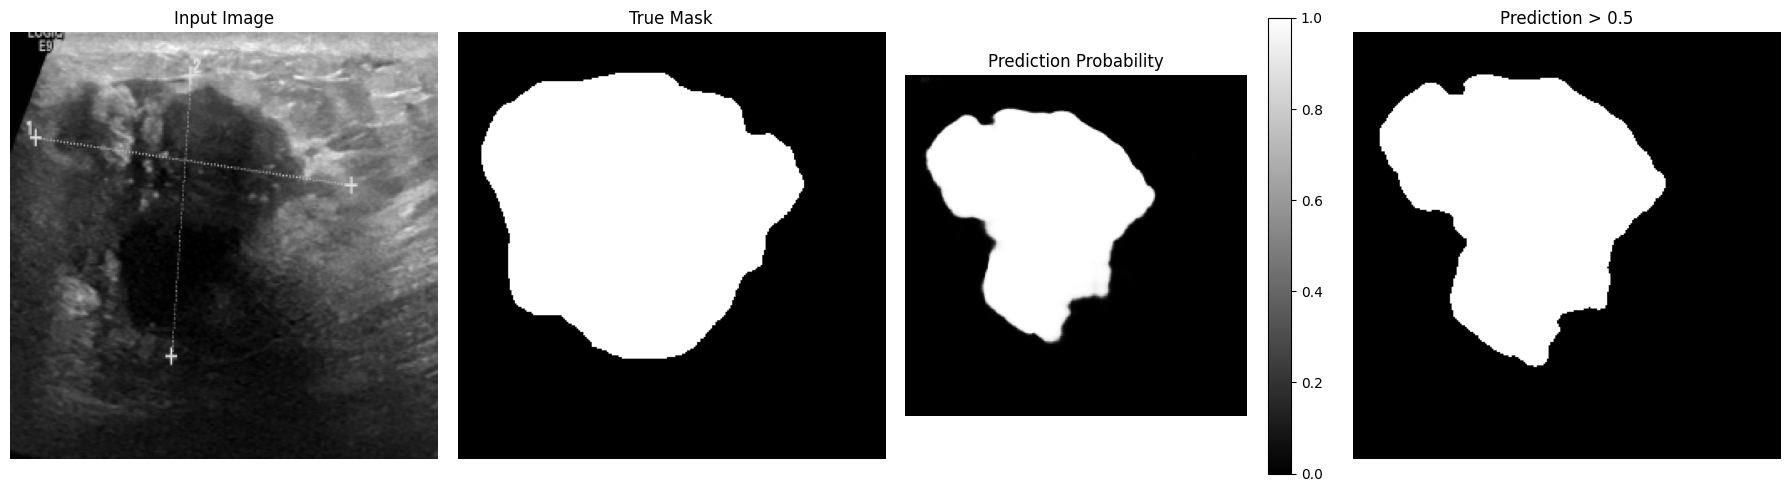

In [ ]:
def show_prediction_with_probability(model, pair):

    img_path, mask_path = pair

    # Load the actual image and mask
    img, mask = load_image_mask(
        img_path.encode(),
        mask_path.encode()
    )

    print("Image shape:", img.shape)
    print("Image dtype:", img.dtype)
    print("Mask shape:", mask.shape)
    print("Mask dtype:", mask.dtype)

    # Make sure model input is float32
    input_img = np.expand_dims(img, axis=0).astype(np.float32)

    print("Model input shape:", input_img.shape)
    print("Model input dtype:", input_img.dtype)

    pred = model.predict(
        input_img,
        verbose=0
    )[0]

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred.squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.colorbar()
    plt.title("Prediction Probability")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow((pred > 0.5).squeeze(), cmap="gray")
    plt.title("Prediction > 0.5")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_prediction_with_probability(model, val_pairs[9])